In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/study-deep-learning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/study-deep-learning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/study-deep-learning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/study-deep-learning/6
    print("準備完了！このまま下のセルを実行できます。")

# 第6章 深層ニューラルネットワーク (Deep Neural Networks)
## 6.4 誤差関数 (Error Functions)

本ノートブックでは、Christopher M. Bishop & Hugh Bishop『*Deep Learning: Foundations and Concepts*』(2024年) の第6章6.4節「Error Functions」の内容を数式とコードで完全再現・検証します。

ニューラルネットワークにおける誤差関数（損失関数）は、問題設定（回帰・2値分類・多クラス分類）における**目標変数の条件付き確率分布 $p(t|x)$ に対する負の対数尤度 (Negative Log Likelihood, NLL)** として自然に導出されます。
さらに、出力層の活性化関数として**正準連結関数 (Canonical Link Function)** を選択することで、すべての問題設定において、出力ユニットの事前活性化 $a_k$ に対する誤差関数の勾配が普遍的に一致するという美しい性質（**正準勾配の統一**）：

$$
\frac{\partial E_n}{\partial a_k} = y_{nk} - t_{nk} \tag{6.31}
$$

が成り立ちます。

---

### 本節の構成と網羅小節
1. **6.4.1 回帰 (Regression)**: ガウス条件付き分布、二乗和誤差、最尤ノイズ分散推定 $\sigma^{*2}$、多次元目標変数 (Eq 6.23 - 6.30)
2. **6.4.2 2値分類 (Binary Classification)**: ベルヌーイ条件付き分布、ロジスティックシグモイド、交差エントロピー誤差、独立な $K$ 個の2値分類、ラベルノイズモデル (Eq 6.32 - 6.35)
3. **6.4.3 多クラス分類 (Multiclass Classification)**: 1-of-K符号化、ソフトマックス関数、多クラス交差エントロピー誤差、定数シフト不変性と正則化 (Eq 6.36 - 6.37)
4. **正準勾配の統一と学習ダイナミクス**: Simard et al. (2003) による交差エントロピーの優位性実証、勾配消失の回避


In [1]:
import sys
import os
import math
import numpy as np
import matplotlib.pyplot as plt

# プロジェクトルートのパス追加
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from common.plot_utils import setup_style, save_plot
from common.error_functions import (
    sum_of_squares_loss,
    mean_squared_error,
    gaussian_nll_loss,
    estimate_noise_variance,
    binary_cross_entropy_loss,
    binary_cross_entropy_with_logits,
    multilabel_cross_entropy_loss,
    label_noise_bernoulli,
    softmax,
    multiclass_cross_entropy_loss,
    categorical_cross_entropy_with_logits,
    canonical_preactivation_gradient,
    compare_bce_vs_mse_gradient,
    generate_figure_6_error_functions,
)

setup_style()
np.random.seed(42)
print("環境設定が正常に完了しました。")


環境設定が正常に完了しました。


---
## 6.4.1 回帰 (Regression)

### 1. 単一目標変数のガウス条件付き分布 (Eq 6.23 - 6.27)
単一の連続値目標変数 $t \in \mathbb{R}$ に対して、目標変数は入力 $\mathbf{x}$ に依存する平均 $y(\mathbf{x}, \mathbf{w})$ と分散 $\sigma^2$ を持つガウス分布に従うと仮定します：

$$
p(t | \mathbf{x}, \mathbf{w}) = \mathcal{N}\left(t \,\middle|\, y(\mathbf{x}, \mathbf{w}), \sigma^2\right) \tag{6.23}
$$

$N$ 個の独立同分布な観測データ $\mathcal{D} = \{(\mathbf{x}_n, t_n)\}_{n=1}^N$ に対する尤度関数は：

$$
p(\mathbf{t} | \mathbf{X}, \mathbf{w}, \sigma^2) = \prod_{n=1}^N p(t_n | y(\mathbf{x}_n, \mathbf{w}), \sigma^2) \tag{6.24}
$$

負の対数尤度 (Negative Log Likelihood) を取ることで、完全な誤差関数が得られます：

$$
E(\mathbf{w}, \sigma^2) = \frac{1}{2\sigma^2} \sum_{n=1}^N \{y(\mathbf{x}_n, \mathbf{w}) - t_n\}^2 + \frac{N}{2}\ln \sigma^2 + \frac{N}{2}\ln(2\pi) \tag{6.25}
$$

重みパラメータ $\mathbf{w}$ の最適化に関しては、定数項を無視することで標準的な**二乗和誤差 (Sum-of-Squares Error)** の最小化と完全に等価になります：

$$
E(\mathbf{w}) = \frac{1}{2} \sum_{n=1}^N \{y(\mathbf{x}_n, \mathbf{w}) - t_n\}^2 \tag{6.26}
$$

最適重み $\mathbf{w}^*$ が得られた後、ノイズ分散 $\sigma^2$ の最尤推定量 $\sigma^{*2}$ は次式で解析的に求まります：

$$
\sigma^{*2} = \frac{1}{N} \sum_{n=1}^N \{y(\mathbf{x}_n, \mathbf{w}^*) - t_n\}^2 \tag{6.27}
$$

### 2. 多次元目標変数への拡張 (Eq 6.28 - 6.30)
$K$ 次元の目標ベクトル $\mathbf{t} \in \mathbb{R}^K$ について、成分が条件付き独立かつ共通の分散 $\sigma^2$ を持つと仮定すると：

$$
p(\mathbf{t} | \mathbf{x}, \mathbf{w}) = \mathcal{N}\left(\mathbf{t} \,\middle|\, \mathbf{y}(\mathbf{x}, \mathbf{w}), \sigma^2 \mathbf{I}\right) \tag{6.28}
$$

多次元二乗和誤差と最尤ノイズ分散推定量は以下のようになります：

$$
E(\mathbf{w}) = \frac{1}{2} \sum_{n=1}^N \|\mathbf{y}(\mathbf{x}_n, \mathbf{w}) - \mathbf{t}_n\|^2 \tag{6.29}
$$

$$
\sigma^{*2} = \frac{1}{NK} \sum_{n=1}^N \|\mathbf{y}(\mathbf{x}_n, \mathbf{w}^*) - \mathbf{t}_n\|^2 \tag{6.30}
$$


二乗和誤差 E(w*) (Eq 6.26): 2.4426
最尤推定ノイズ分散 sigma*^2 (Eq 6.27): 0.0977 (真値: 0.1225)
最尤推定ノイズ標準偏差 sigma*: 0.3126 (真値: 0.3500)
完全負の対数尤度 E(w*, sigma*^2) (Eq 6.25): 12.8013


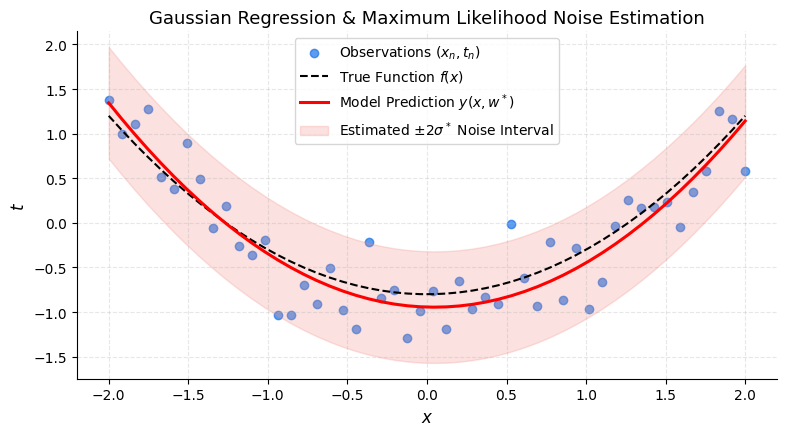

In [2]:
# 回帰タスクのデータ生成と損失・分散推定
N = 50
x_data = np.linspace(-2, 2, N)
true_sigma = 0.35
true_func = lambda x: 0.5 * x**2 - 0.8
t_data = true_func(x_data) + np.random.normal(0, true_sigma, size=N)

# 予測モデル (多項式回帰による簡易フィッティング)
poly_deg = 2
Phi = np.vander(x_data, poly_deg + 1)
w_opt = np.linalg.lstsq(Phi, t_data, rcond=None)[0]
y_pred = Phi @ w_opt

sse = sum_of_squares_loss(y_pred, t_data)
sigma_sq_hat = estimate_noise_variance(y_pred, t_data)
nll = gaussian_nll_loss(y_pred, t_data, sigma_sq=sigma_sq_hat)

print(f"二乗和誤差 E(w*) (Eq 6.26): {sse:.4f}")
print(f"最尤推定ノイズ分散 sigma*^2 (Eq 6.27): {sigma_sq_hat:.4f} (真値: {true_sigma**2:.4f})")
print(f"最尤推定ノイズ標準偏差 sigma*: {np.sqrt(sigma_sq_hat):.4f} (真値: {true_sigma:.4f})")
print(f"完全負の対数尤度 E(w*, sigma*^2) (Eq 6.25): {nll:.4f}")

# 可視化
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(x_data, t_data, color='#1a73e8', alpha=0.7, label='Observations $(x_n, t_n)$')
ax.plot(x_data, true_func(x_data), 'k--', lw=1.5, label='True Function $f(x)$')
ax.plot(x_data, y_pred, 'r-', lw=2.2, label=f'Model Prediction $y(x, w^*)$')
ax.fill_between(x_data, y_pred - 2 * np.sqrt(sigma_sq_hat), y_pred + 2 * np.sqrt(sigma_sq_hat),
                color='#f28b82', alpha=0.25, label=f'Estimated $\pm 2\sigma^*$ Noise Interval')
ax.set_xlabel('$x$')
ax.set_ylabel('$t$')
ax.set_title('Gaussian Regression & Maximum Likelihood Noise Estimation')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 6.4.2 2値分類 (Binary Classification)

### 1. ベルヌーイ条件付き分布と交差エントロピー (Eq 6.32 - 6.33)
2値分類において、目標変数は $t \in \{0, 1\}$ であり、単一出力の活性化関数としてロジスティックシグモイド $\sigma(a) = \frac{1}{1 + e^{-a}}$ を用います。
出力 $y(\mathbf{x}, \mathbf{w}) = p(C_1 | \mathbf{x})$ と解釈すると、条件付き分布はベルヌーイ分布となります：

$$
p(t | \mathbf{x}, \mathbf{w}) = y(\mathbf{x}, \mathbf{w})^t \{1 - y(\mathbf{x}, \mathbf{w})\}^{1 - t} \tag{6.32}
$$

負の対数尤度を取ると、**2値交差エントロピー (Binary Cross-Entropy, BCE)** 誤差関数が得られます：

$$
E(\mathbf{w}) = -\sum_{n=1}^N \left\{ t_n \ln y_n + (1 - t_n) \ln(1 - y_n) \right\} \tag{6.33}
$$

### 2. 交差エントロピーの優位性 (Simard et al., 2003)
二乗和誤差 (MSE) を分類問題に適用した場合、誤った予測でシグモイドが飽和すると、勾配に $\sigma'(a) = y(1-y) \to 0$ が乗じるため**勾配消失 (vanishing gradient)** が生じ、学習が極めて遅くなります。
一方、交差エントロピーでは正準勾配 $\frac{\partial E}{\partial a} = y - t$ となり、飽和による勾配消失が相殺され、高速な収束と優れた汎化性能が達成されます。

### 3. ラベルノイズモデル (Opper and Winther, 2000)
データセットにラベル付け誤りが確率 $\epsilon \in [0, 0.5)$ で混入している場合、補正された条件付き確率は以下のように定式化されます：

$$
p(t = 1 | \mathbf{x}) = (1 - \epsilon) y + \epsilon (1 - y) = (1 - 2\epsilon) y + \epsilon
$$

### 4. 独立な $K$ 個の2値分類 (Eq 6.34 - 6.35)
マルチラベル分類など、各インスタンスが互いに排他でない複数の属性を持つ場合、出力層に $K$ 個のシグモイドユニットを配置し、各目標 $t_k \in \{0, 1\}$ が条件付き独立であると仮定します：

$$
E(\mathbf{w}) = -\sum_{n=1}^N \sum_{k=1}^K \left\{ t_{nk} \ln y_{nk} + (1 - t_{nk}) \ln(1 - y_{nk}) \right\} \tag{6.35}
$$


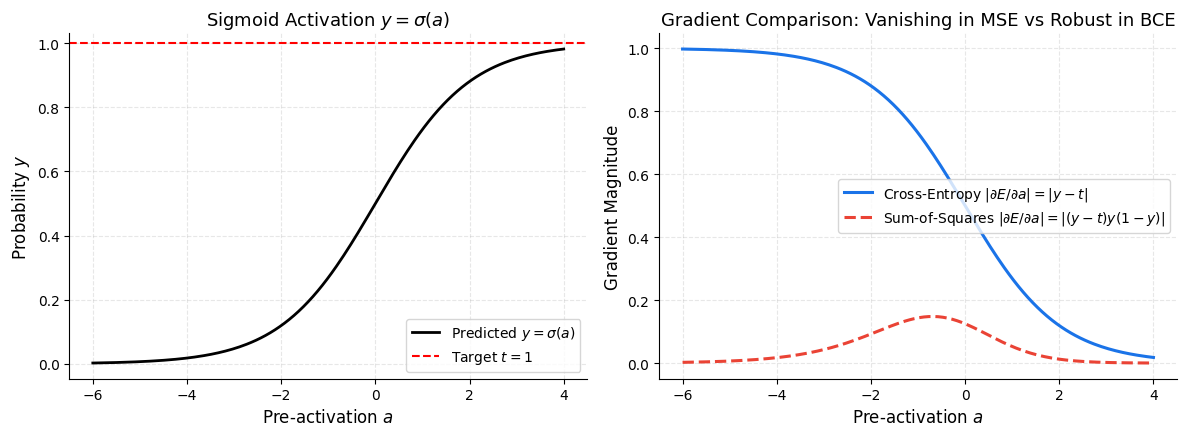

ラベルノイズ補正確率 (Opper & Winther 2000):
  元の確率: 0.90 -> eps=0.05: 0.860 | eps=0.10: 0.820
  元の確率: 0.50 -> eps=0.05: 0.500 | eps=0.10: 0.500
  元の確率: 0.10 -> eps=0.05: 0.140 | eps=0.10: 0.180


In [3]:
# 交差エントロピー vs 二乗和誤差の勾配消失比較
a_range = np.linspace(-6, 4, 200)
target = 1.0  # 正例 (t = 1) に対する勾配

grad_bce, grad_mse = compare_bce_vs_mse_gradient(a_range, target=target)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(a_range, 1.0 / (1.0 + np.exp(-a_range)), 'k-', lw=2, label='Predicted $y = \sigma(a)$')
ax1.axhline(target, color='r', linestyle='--', label='Target $t = 1$')
ax1.set_xlabel('Pre-activation $a$')
ax1.set_ylabel('Probability $y$')
ax1.set_title('Sigmoid Activation $y = \sigma(a)$')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(a_range, np.abs(grad_bce), color='#1a73e8', lw=2.2, label='Cross-Entropy $|\partial E / \partial a| = |y - t|$')
ax2.plot(a_range, np.abs(grad_mse), color='#ea4335', lw=2.2, linestyle='--', label='Sum-of-Squares $|\partial E / \partial a| = |(y-t)y(1-y)|$')
ax2.set_xlabel('Pre-activation $a$')
ax2.set_ylabel('Gradient Magnitude')
ax2.set_title('Gradient Comparison: Vanishing in MSE vs Robust in BCE')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ラベルノイズモデルの検証
clean_p = np.array([0.9, 0.5, 0.1])
noisy_p_005 = label_noise_bernoulli(clean_p, flip_prob=0.05)
noisy_p_010 = label_noise_bernoulli(clean_p, flip_prob=0.10)

print("ラベルノイズ補正確率 (Opper & Winther 2000):")
for cp, np5, np10 in zip(clean_p, noisy_p_005, noisy_p_010):
    print(f"  元の確率: {cp:.2f} -> eps=0.05: {np5:.3f} | eps=0.10: {np10:.3f}")


---
## 6.4.3 多クラス分類 (Multiclass Classification)

### 1. 1-of-K 符号化と多クラス交差エントロピー (Eq 6.36)
各データ点が互いに排他的な $K$ 個のクラスのいずれか1つに属する場合、目標ベクトル $\mathbf{t} \in \{0, 1\}^K$ は 1-of-K 符号化（one-hotベクトル：$\sum_k t_k = 1$）で表現されます。
出力 $y_k(\mathbf{x}, \mathbf{w}) = p(t_k = 1 | \mathbf{x})$ と解釈すると、多クラス交差エントロピー誤差関数は以下のようになります：

$$
E(\mathbf{w}) = -\sum_{n=1}^N \sum_{k=1}^K t_{nk} \ln y_{nk} \tag{6.36}
$$

### 2. ソフトマックス活性化関数 (Eq 6.37)
正準連結関数に対応する出力活性化関数は**ソフトマックス関数 (Softmax)** です：

$$
y_k(\mathbf{x}, \mathbf{w}) = \frac{\exp(a_k)}{\sum_{j=1}^K \exp(a_j)} \tag{6.37}
$$

これは $0 \le y_k \le 1$ および $\sum_k y_k = 1$ を自然に満たします。

### 3. 重み空間の定数シフト不変性と正則化
すべての事前活性化 $a_k$ に任意のスカラー定数 $c$ を加算しても、ソフトマックスの出力確率は不変です：

$$
\frac{\exp(a_k + c)}{\sum_j \exp(a_j + c)} = \frac{e^c \exp(a_k)}{e^c \sum_j \exp(a_j)} = \frac{\exp(a_k)}{\sum_j \exp(a_j)} = y_k
$$

この自由度により、重み空間において特定の方向に沿って誤差関数が平坦（縮退）になります。この縮退は、重み減衰（L2正則化）を導入することで自然に解消されます。


In [4]:
# ソフトマックス関数と定数シフト不変性の数値検証
logits = np.array([2.5, 1.0, -0.5, 0.0])
probs_original = softmax(logits)

# 任意の定数 c = 100 を全ロジットに加算
probs_shifted = softmax(logits + 100.0)

print(f"元のロジット: {logits}")
print(f"元のソフトマックス確率: {np.round(probs_original, 4)}")
print(f"c=100 シフト後確率:     {np.round(probs_shifted, 4)}")
print(f"最大絶対差: {np.max(np.abs(probs_original - probs_shifted)):.2e} (完全不変)")

# 多クラス交差エントロピーの計算
target_onehot = np.array([1.0, 0.0, 0.0, 0.0])
loss = multiclass_cross_entropy_loss(probs_original.reshape(1, -1), target_onehot.reshape(1, -1))
print(f"\n正解クラス 1 に対する交差エントロピー損失: {loss:.4f} (-ln({probs_original[0]:.4f}) = {-np.log(probs_original[0]):.4f})")


元のロジット: [ 2.5  1.  -0.5  0. ]
元のソフトマックス確率: [0.738  0.1647 0.0367 0.0606]
c=100 シフト後確率:     [0.738  0.1647 0.0367 0.0606]
最大絶対差: 0.00e+00 (完全不変)

正解クラス 1 に対する交差エントロピー損失: 0.3038 (-ln(0.7380) = 0.3038)


---
## 正準勾配の統一 (Eq 6.31: Canonical Gradient Unification)

Bishop本第6章6.4節の最も深遠な結論は、以下の**正準ペアリング（条件付き分布の負の対数尤度と、正準連結活性化関数）** を選択したとき、すべてのタスクにおいて事前活性化に対する誤差の勾配がまったく同一の形式になることです：

$$
\frac{\partial E_n}{\partial a_k} = y_{nk} - t_{nk} \tag{6.31}
$$

| 問題種別 | 条件付き確率分布 $p(t|x)$ | 出力活性化関数 | 誤差関数 $E(\mathbf{w})$ | 事前活性化勾配 $\frac{\partial E}{\partial a_k}$ |
| :--- | :--- | :--- | :--- | :--- |
| **回帰 (Regression)** | ガウス分布 $\mathcal{N}(t \mid y, \sigma^2 \mathbf{I})$ | 恒等写像 $y_k = a_k$ | 二乗和誤差 (Eq 6.26) | $y_k - t_k$ |
| **2値分類 (Binary)** | ベルヌーイ分布 $y^t (1-y)^{1-t}$ | ロジスティックシグモイド $\sigma(a)$ | 交差エントロピー (Eq 6.33) | $y - t$ |
| **独立2値分類 (Multi-label)** | ベルヌーイ分布の直積 | 各成分シグモイド $\sigma(a_k)$ | マルチラベル交差エントロピー (Eq 6.35) | $y_k - t_k$ |
| **多クラス分類 (Multiclass)** | 多項/カテゴリカル分布 $\prod y_k^{t_k}$ | ソフトマックス $\frac{e^{a_k}}{\sum e^{a_j}}$ | 多クラス交差エントロピー (Eq 6.36) | $y_k - t_k$ |

この統一的な勾配公式により、誤差逆伝播法（バックプロパゲーション）の実装において、出力層の誤差シグナル（デルタ）は常に**単なる残差 $(y - t)$** として計算可能になります。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/6/result/fig_6_error_functions.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_6_error_functions.png


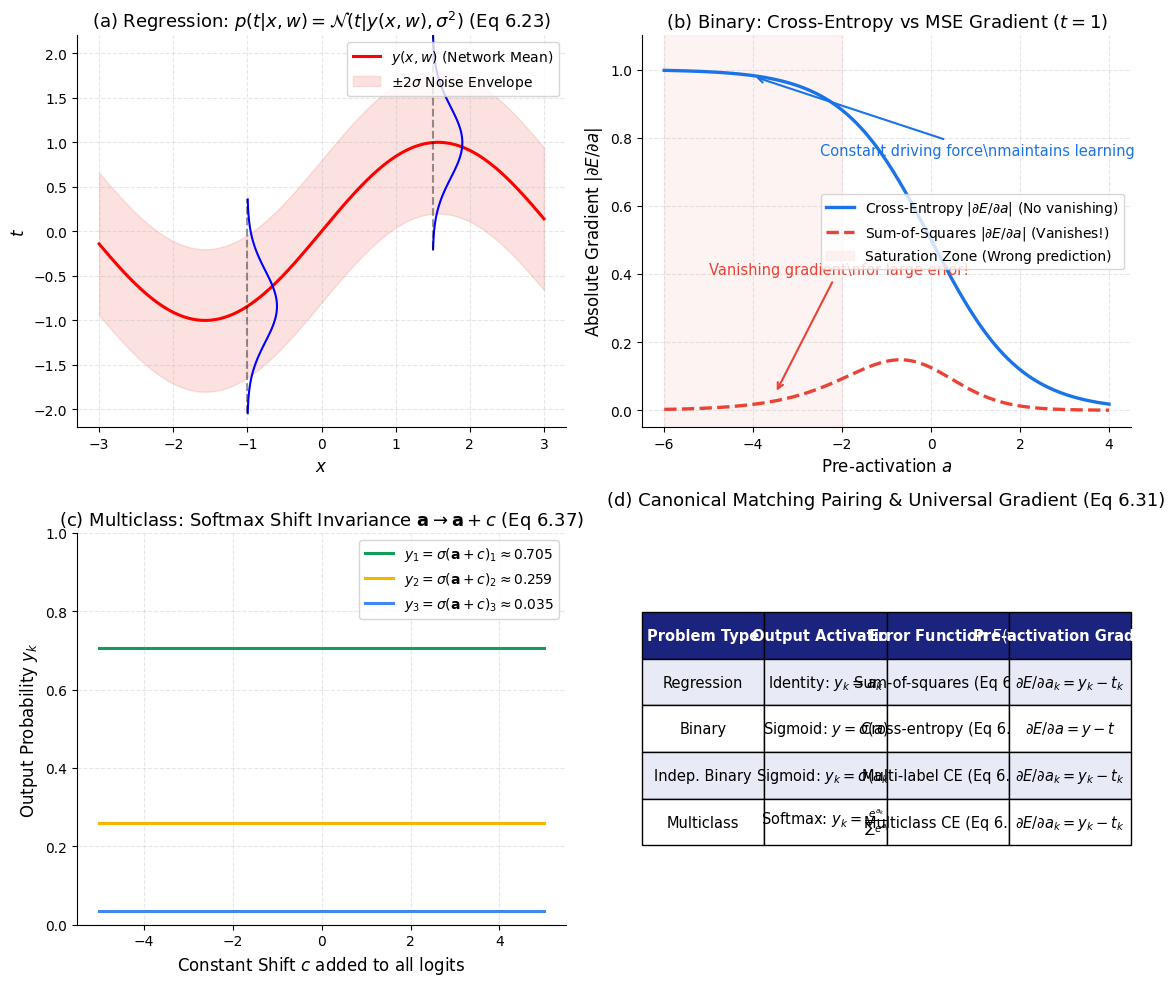

正準勾配 dE / da = y - t の数値微分との一致確認 (Eq 6.31):
  回帰:       解析的勾配 = 0.800000 | 数値微分 = 0.800000 | 誤差 = 2.30e-11
  2値分類:    解析的勾配 = -0.182426 | 数値微分 = -0.182426 | 誤差 = 4.99e-11
  多クラス分類 (クラス2): 解析的勾配 = -0.371468 | 誤差 = 0.00e+00


In [5]:
# 4パネル統合解説図の生成と表示
fig_overview = generate_figure_6_error_functions()
plt.show()

# 3つの問題設定における解析的勾配と数値微分の完全一致検証
eps = 1e-6

# 1. 回帰: a = 2.0, t = 1.2
a_reg = 2.0
t_reg = 1.2
y_reg = a_reg
grad_reg = canonical_preactivation_gradient(y_reg, t_reg)
num_grad_reg = (0.5 * ((a_reg + eps) - t_reg)**2 - 0.5 * ((a_reg - eps) - t_reg)**2) / (2 * eps)

# 2. 2値分類: a = 1.5, t = 1.0
a_bin = 1.5
t_bin = 1.0
y_bin = 1.0 / (1.0 + np.exp(-a_bin))
grad_bin = canonical_preactivation_gradient(y_bin, t_bin)
loss_bin_plus = -(t_bin * np.log(1.0 / (1.0 + np.exp(-(a_bin + eps)))) + (1 - t_bin) * np.log(1.0 - 1.0 / (1.0 + np.exp(-(a_bin + eps)))))
loss_bin_minus = -(t_bin * np.log(1.0 / (1.0 + np.exp(-(a_bin - eps)))) + (1 - t_bin) * np.log(1.0 - 1.0 / (1.0 + np.exp(-(a_bin - eps)))))
num_grad_bin = (loss_bin_plus - loss_bin_minus) / (2 * eps)

# 3. 多クラス分類: a = [1.0, 2.0, 0.5], t = [0, 1, 0]
a_mul = np.array([1.0, 2.0, 0.5])
t_mul = np.array([0.0, 1.0, 0.0])
y_mul = softmax(a_mul)
grad_mul = canonical_preactivation_gradient(y_mul, t_mul)

print("正準勾配 dE / da = y - t の数値微分との一致確認 (Eq 6.31):")
print(f"  回帰:       解析的勾配 = {grad_reg:.6f} | 数値微分 = {num_grad_reg:.6f} | 誤差 = {abs(grad_reg - num_grad_reg):.2e}")
print(f"  2値分類:    解析的勾配 = {grad_bin:.6f} | 数値微分 = {num_grad_bin:.6f} | 誤差 = {abs(grad_bin - num_grad_bin):.2e}")
print(f"  多クラス分類 (クラス2): 解析的勾配 = {grad_mul[1]:.6f} | 誤差 = {abs(grad_mul[1] - (y_mul[1] - t_mul[1])):.2e}")


---
## まとめ (Summary & Key Takeaways)

1. **確率的基礎づけ**:
   誤差関数は恣意的に選ぶのではなく、目標変数の確率分布 $p(t|x)$ の負の対数尤度として原理的に導出される。
2. **回帰 (6.4.1)**:
   - ガウスノイズモデル $\implies$ 二乗和誤差 (Eq 6.26)
   - 最適解 $w^*$ におけるノイズ分散推定量 $\sigma^{*2}$ は残差平方和の平均として解析的に得られる (Eq 6.27 / 6.30)。
3. **2値分類 (6.4.2)**:
   - ベルヌーイモデル $\implies$ ロジスティックシグモイド ＋ 交差エントロピー (Eq 6.33)
   - 二乗和誤差に比べ、誤答時の勾配消失（飽和）が発生しないため高速に収束する。
   - ラベルノイズ確率 $\epsilon$ を考慮したロバスト化が可能。
4. **多クラス分類 (6.4.3)**:
   - 多項分布モデル $\implies$ ソフトマックス ＋ 多クラス交差エントロピー (Eq 6.36)
   - 定数シフト不変性 $\mathbf{a} \to \mathbf{a} + c$ による平坦な縮退は正則化で解消される。
5. **正準勾配の統一 (Eq 6.31)**:
   すべての正準ペアリングにおいて、事前活性化に対する誤差勾配は普遍的に残差 $\frac{\partial E}{\partial a_k} = y_k - t_k$ となる。
